In [ ]:
#Sơ lược về dữ liệu
import pandas as pd

df = pd.read_csv('../data/Crop_recommendation.csv')

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
#kích thước của dataset
df.shape

(2200, 8)

In [ ]:
#Thông tin tổng quan về dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [ ]:
#Mô tả tóm tắt các đặc trưng số của dataset
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
#Có dữ liệu bị thiếu trong dataset không?
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [ ]:
#Kiểm tra xem có dữ liệu trùng lặp trong dataset không
df.duplicated().sum()

np.int64(0)

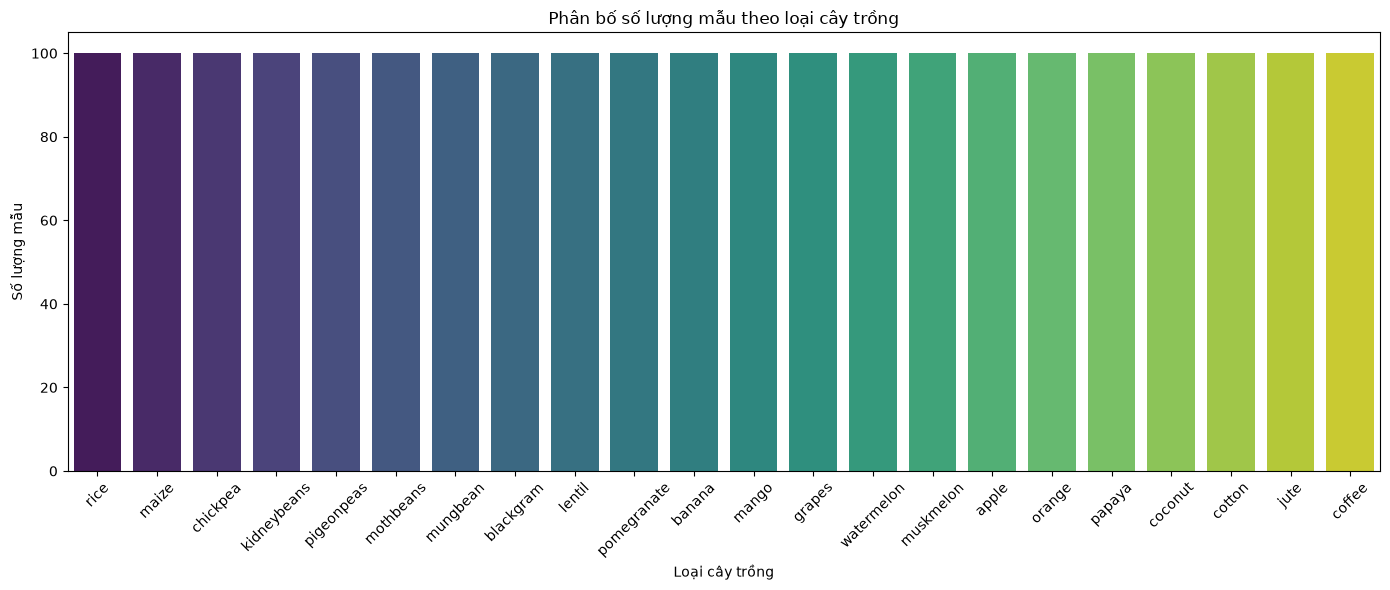

In [ ]:
#biểu đồ phân bố số lượng mẫu theo loại cây trồng
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.countplot(
    x='label',
    hue='label',
    data=df,
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)
plt.title('Phân bố số lượng mẫu theo loại cây trồng')
plt.xlabel('Loại cây trồng')
plt.ylabel('Số lượng mẫu')

plt.tight_layout()
plt.show()

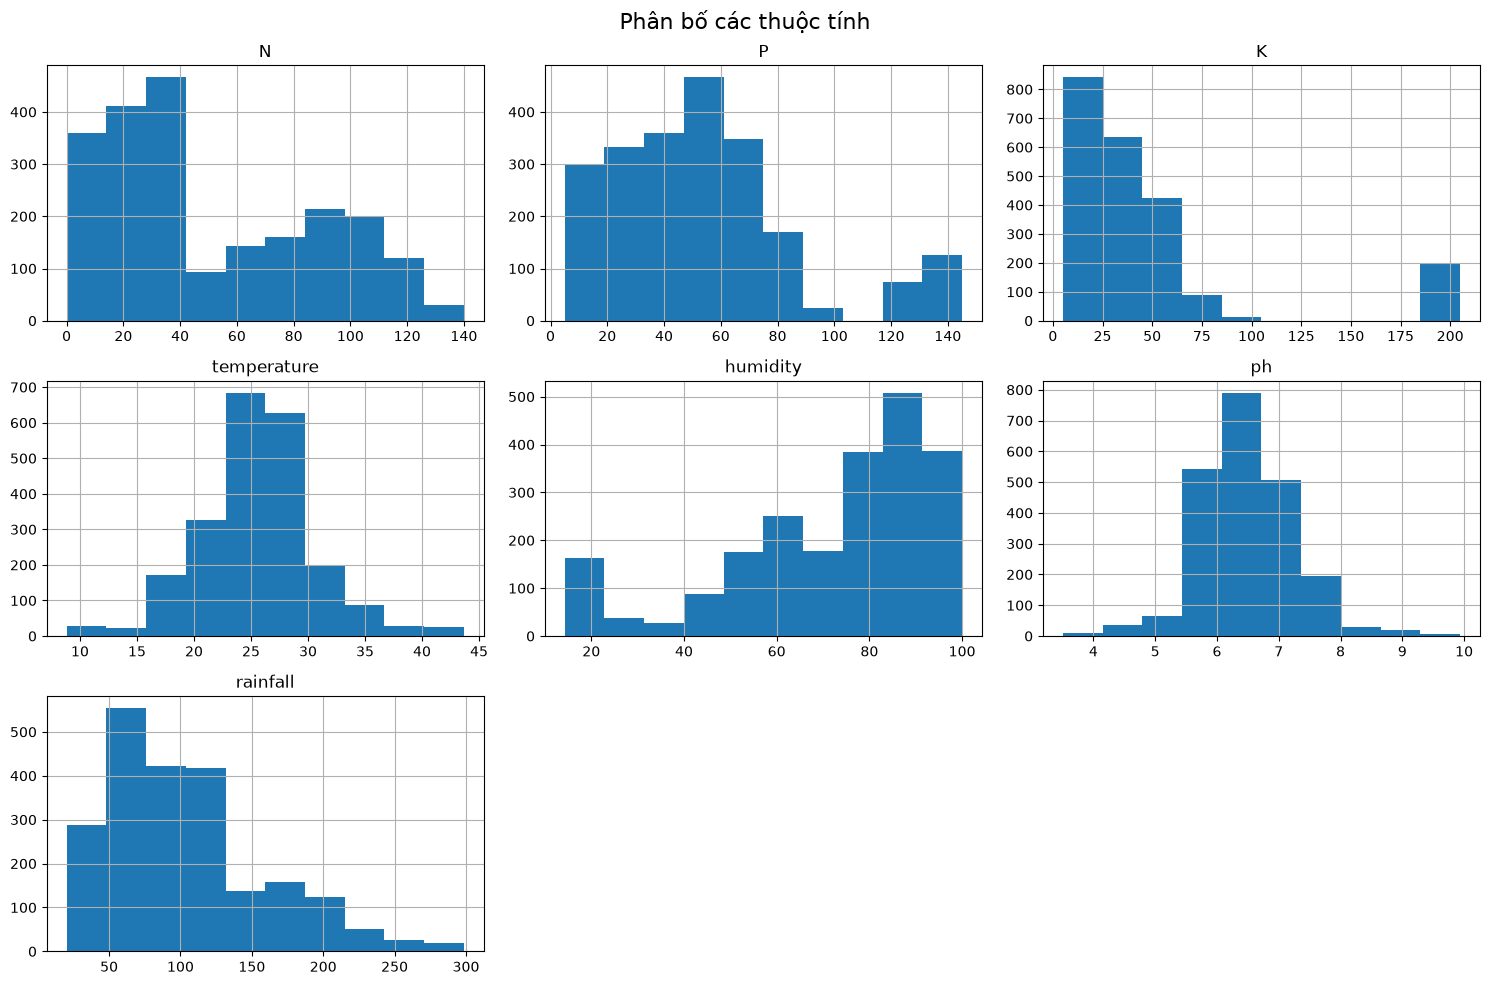

In [11]:
#biểu đồ phân bố các thuộc tính
df.hist(figsize=(15,10))

plt.suptitle('Phân bố các thuộc tính', fontsize=16)

plt.tight_layout()
plt.show()

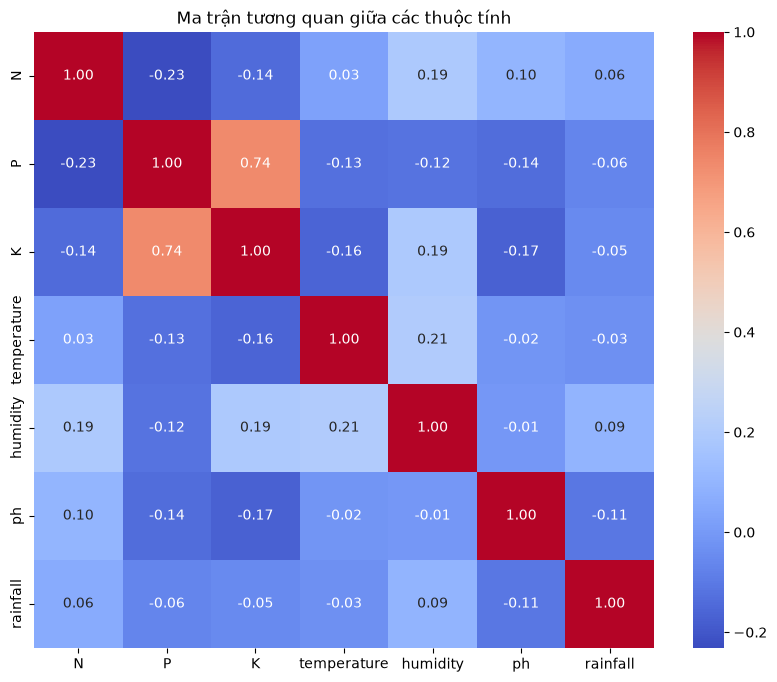

In [12]:
#mức độ tương quan giữa các đặc trưng
plt.figure(figsize=(10,8))

corr = df.drop('label', axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Ma trận tương quan giữa các thuộc tính')

plt.show()

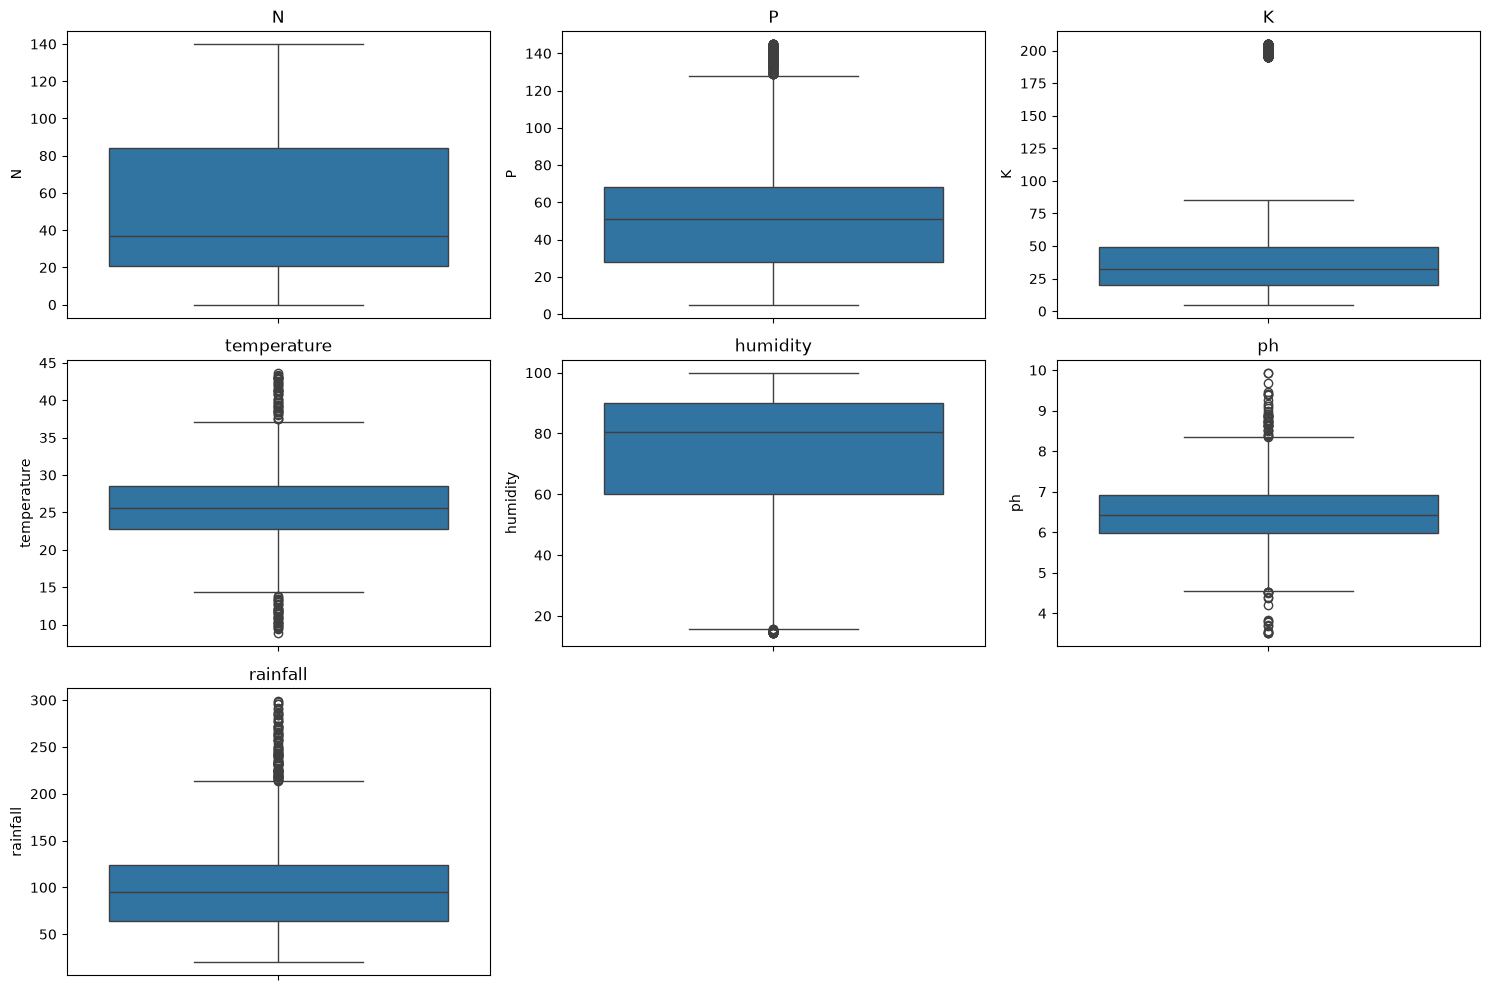

In [13]:
#phát hiện có giá trị nào bất thường trong các đặc trưng số không
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns[:-1]):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [15]:
# Tách đặc trưng và nhãn
X = df.drop('label', axis=1)
y = df['label']

# Chia train và test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1760, 7)
X_test: (440, 7)
y_train: (1760,)
y_test: (440,)


In [16]:
#chuẩn hóa dữ liệu đối với KNN, SVM
from sklearn.preprocessing import StandardScaler

# Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# Chuẩn hóa dữ liệu train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (1760, 7)
X_test_scaled: (440, 7)
